<a href="https://www.kaggle.com/code/cath4444/graphene-to-phoneme-sequence-modelling?scriptVersionId=320070776" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
import urllib.request
import os
from torch.utils.data import DataLoader, Dataset 
import pandas as pd
from collections import Counter
import csv
import editdistance
import random
def set_seed(seed=42): 
    random.seed(seed)
    np.random.seed(seed)             
    torch.manual_seed(seed)          
    torch.cuda.manual_seed(seed)     
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# 0. AI Usage Declaration 
For my implementation in the notebook, GenAI was used to debug errors in my code, and helping me understand why specific things raised an error. For the report, AI helped me structure my tables, and identify weaknesses in my arguments. 

In [2]:
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
kaggle = False 
if kaggle:   
    DIR_PATH = '/kaggle/input/datasets/cath4444/graphemes-to-phonemes/'
else:
    DIR_PATH = '/data/'
    
TRAIN_FILE = 'g2p_train.csv'
TEST_FILE = 'g2p_test.csv'
VAL_FILE = 'g2p_val.csv'

# 1. Data Processing

In [4]:

def read_data(filepath: str):
    data = []
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"file not found at {filepath}")
    
    with open(filepath, 'r', encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            data.append(row)
        
    if not data:
        raise ValueError(f"no data loaded from {filepath}")
    
    words  = [row['word'] for row in data]
    phonemes = [row['phonemes'] for row in data]

    return words, phonemes

        
train_words, train_phonemes = read_data(DIR_PATH+TRAIN_FILE)
test_words, test_phonemes = read_data(DIR_PATH+TEST_FILE)
val_words, val_phonemes = read_data(DIR_PATH+VAL_FILE)


print(f"Size of Train Dataset: {len(train_words):,}")
print(f"Size of Test Dataset: {len(test_words):,}")
print(f"Size of Validation Dataset: {len(val_words):,}")
print(f"\nFirst 2 samples:\n{train_words[:2]} {train_phonemes[:2]}\n")

Size of Train Dataset: 92,426
Size of Test Dataset: 11,554
Size of Validation Dataset: 11,553

First 2 samples:
['vigil', 'ethelinda'] ['V IH1 JH AH0 L', 'EH0 TH EH0 L IY1 N D AH0']



In [5]:
# word length and sequence length 
def plot_data_hist(lengths, label):
    plt.figure(figsize=(8, 5))
    plt.hist(lengths, range(min(lengths), max(lengths) + 2),
                edgecolor='black')

    plt.xlabel(label)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {label}s")
    plt.show()


really long word at index 35284: supercalifragilisticexpealidoshus
really long word at index 56137: deinstitutionalization
really long word at index 72394: antidisestablishmentarianism


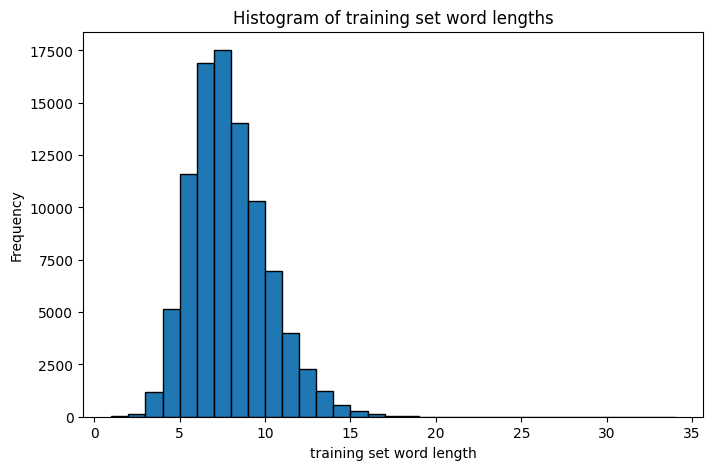

In [6]:
word_lengths = []
for i, w in enumerate(train_words): 
    if isinstance(w, str):
        word_lengths.append(len(w)) 
        if len(w) > 20:
             print(f"really long word at index {i}:",w)
    else:
        print(f"at index {i}: ")
        print(w)

plot_data_hist(word_lengths, "training set word length")

really long phoneme at index 35284: S UW2 P ER0 K AE2 L AH0 F R AE1 JH AH0 L IH2 S T IH0 K EH2 K S P IY0 AE2 L AH0 D OW1 SH AH0 S
really long phoneme at index 72394: AE2 N T AY0 D IH0 S AH0 S T AE2 B L IH0 SH M AH0 N T EH1 R IY0 AH0 N IH0 Z AH0 M


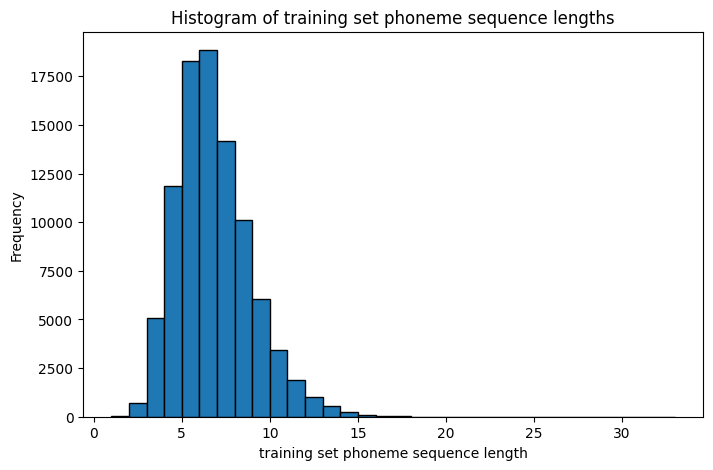

In [7]:
phoneme_lengths = []
for i, seq in enumerate(train_phonemes): 
    if isinstance(seq, str):
        s_len = len(seq.split())
        phoneme_lengths.append(s_len) 
        if s_len > 20:
             print(f"really long phoneme at index {i}:",seq)
    else:
        print(f"at index {i}: ")
        print(w)

plot_data_hist(phoneme_lengths, "training set phoneme sequence length")

In [8]:
def build_vocab(texts, level = "char", vocab_size=100):
    """
        Build word-to-index mapping from a list of strings.
        args: 
            level: {char, word}
    """
    counter = Counter()
    if level == "char":
        for text in texts:
            counter.update(list(text))
        
    elif level == "word":
        for text in texts:
            counter.update(text.split())

    token_to_idx = {"<PAD>": 0, "<SOS>":1, "<EOS>":2, "<UNK>": 3}
    for w, _ in counter.most_common(vocab_size - 4):
        token_to_idx[w] = len(token_to_idx)
    return token_to_idx

In [9]:
char_to_index = build_vocab(train_words, level="char")
CHAR_VOCAB_SIZE = len(char_to_index)
print(f"Size of char Vocabulary: {CHAR_VOCAB_SIZE}")
print(f"first few entries: {list(char_to_index.items())[:6]}")

print()

phoneme_to_index = build_vocab(train_phonemes, level="word")
PHONEME_VOCAB_SIZE = len(phoneme_to_index)
print(f"Size of phoneme Vocabulary: {PHONEME_VOCAB_SIZE}")
print(f"first few entries: {list(phoneme_to_index.items())[:6]}")

Size of char Vocabulary: 30
first few entries: [('<PAD>', 0), ('<SOS>', 1), ('<EOS>', 2), ('<UNK>', 3), ('e', 4), ('a', 5)]

Size of phoneme Vocabulary: 73
first few entries: [('<PAD>', 0), ('<SOS>', 1), ('<EOS>', 2), ('<UNK>', 3), ('AH0', 4), ('N', 5)]


In [10]:
index_to_phoneme = {}
for phoneme in phoneme_to_index.keys():
    index_to_phoneme[phoneme_to_index[phoneme]]= phoneme
print(f"first few entries: {list(index_to_phoneme.items())[:6]}")

print()

index_to_char = {}
for char in char_to_index.keys():
    index_to_char[char_to_index[char]]= char
print(f"first few entries: {list(index_to_char.items())[:6]}")

first few entries: [(0, '<PAD>'), (1, '<SOS>'), (2, '<EOS>'), (3, '<UNK>'), (4, 'AH0'), (5, 'N')]

first few entries: [(0, '<PAD>'), (1, '<SOS>'), (2, '<EOS>'), (3, '<UNK>'), (4, 'e'), (5, 'a')]


In [11]:
class G2PDataset(Dataset):
    def __init__(self, words, phonemes, char_to_index, phoneme_to_index, transform =None, max_len = 30):

        self.transform = transform 

        self.word_input = [
            torch.tensor(
                self._encode_tokens(
                    list(word), 
                    char_to_index, 
                    max_len=max_len
                ), 
                dtype=torch.long
            )
            for word in words
        ]
        self.phonemes_seq_label = [
            torch.tensor(
                self._encode_tokens(
                    ["<SOS>"]+phoneme.split()+["<EOS>"], 
                    phoneme_to_index, 
                    max_len=max_len
                    ), 
                dtype=torch.long
                )
            for phoneme in phonemes
        ]

    def __len__(self):
        return len(self.word_input)
    
    def __getitem__(self, index):
        return (self.word_input[index], self.phonemes_seq_label[index])

    @staticmethod
    def _encode_tokens(tokens, token_to_idx, max_len=30):
        tokens = tokens[:max_len]

        ids = [
            token_to_idx.get(tok, token_to_idx["<UNK>"])
            for tok in tokens
        ]

        return ids

def collate_with_padding(batch):
    """
        Implement collate fn to create DataLoaders with padding: in each batch, pad all source
        sequences to the same length and all target sequences to the same length, with <PAD> = 0.
    """
    chars_seq_src = [item[0] for item in batch]
    phonemes_seq_label = [item[1] for item in batch]
    
    padded_phonemes = pad_sequence(phonemes_seq_label, batch_first=True, padding_value=0)
    padded_char = pad_sequence(chars_seq_src, batch_first=True, padding_value=0)

    return padded_char, padded_phonemes



In [12]:
BATCH_SIZE = 256
MAX_LEN = 30

train_dataset = G2PDataset(train_words, train_phonemes, char_to_index ,phoneme_to_index, max_len=MAX_LEN)
train_loader = DataLoader(train_dataset, collate_fn=collate_with_padding,batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)

In [13]:

val_dataset = G2PDataset(val_words, val_phonemes, char_to_index ,phoneme_to_index, max_len=MAX_LEN)
val_loader = DataLoader(val_dataset, collate_fn=collate_with_padding,batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)

test_dataset = G2PDataset(test_words, test_phonemes, char_to_index ,phoneme_to_index, max_len=MAX_LEN)
test_loader = DataLoader(test_dataset, collate_fn=collate_with_padding,batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)



# 2. LSTM cell

In [14]:
class LSTMCellWithContext(nn.Module):
    """
    Single LSTM cell implementing the six gating equations.
    params:
        input_size:  dimensionality of input x_t
        hidden_size: dimensionality of hidden state h_t and cell state c_t
        context_mode: context_mode in {"none", "fixed", "attn"}
    """
    def __init__(self, input_size, hidden_size, with_context: bool = False):
        super().__init__()
        self.hidden_size = hidden_size
        self.with_context = with_context

        # Forget gate
        self.W_f = nn.Linear(input_size,  hidden_size, bias=False)
        self.U_f = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_f = nn.Parameter(torch.zeros(hidden_size))

        # Input gate
        self.W_i = nn.Linear(input_size,  hidden_size, bias=False)
        self.U_i = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_i = nn.Parameter(torch.zeros(hidden_size))

        # Output gate
        self.W_o = nn.Linear(input_size,  hidden_size, bias=False)
        self.U_o = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_o = nn.Parameter(torch.zeros(hidden_size))

        # Cell content
        self.W_c = nn.Linear(input_size,  hidden_size, bias=False)
        self.U_c = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_c = nn.Parameter(torch.zeros(hidden_size))

        if with_context: # context weights
            self.V_f = nn.Linear(hidden_size, hidden_size, bias=False) 
            self.V_i = nn.Linear(hidden_size, hidden_size, bias=False)
            self.V_o = nn.Linear(hidden_size, hidden_size, bias=False)
            self.V_c = nn.Linear(hidden_size, hidden_size, bias=False)


    def forward(self, x, h_prev, c_prev, z = None):
        """
        Compute one LSTM timestep.
        params:
            x:      input at current timestep, shape (batch, input_size)
            h_prev: previous hidden state,     shape (batch, hidden_size)
            c_prev: previous cell state,       shape (batch, hidden_size)
            encoder_outputs: ignore if no context is needed 
        returns:
            h: new hidden state, shape (batch, hidden_size)
            c: new cell state,   shape (batch, hidden_size)
        """
        if self.with_context:
            f = torch.sigmoid(self.W_f(x) + self.U_f(h_prev) + self.V_f(z) + self.b_f)   # (batch, hidden_size)
            i = torch.sigmoid(self.W_i(x) + self.U_i(h_prev) + self.V_i(z) + self.b_i)   # (batch, hidden_size)
            o = torch.sigmoid(self.W_o(x) + self.U_o(h_prev) + self.V_o(z) + self.b_o)   # (batch, hidden_size)
            c_tilde = torch.tanh(self.W_c(x) + self.U_c(h_prev) + self.V_c(z) + self.b_c)  # (batch, hidden_size)
        
        else:
            f = torch.sigmoid(self.W_f(x) + self.U_f(h_prev) + self.b_f)   # (batch, hidden_size)
            i = torch.sigmoid(self.W_i(x) + self.U_i(h_prev) + self.b_i)   # (batch, hidden_size)
            o = torch.sigmoid(self.W_o(x) + self.U_o(h_prev) + self.b_o)   # (batch, hidden_size)
            c_tilde = torch.tanh(self.W_c(x) + self.U_c(h_prev) + self.b_c)  # (batch, hidden_size)
        

        c = f * c_prev + i * c_tilde                                       # (batch, hidden_size)
        h = o * torch.tanh(c)                                              # (batch, hidden_size)
        return h, c



# 3. Encoder-Decoder 

In [15]:
    
class LSTMModelWithContext(nn.Module):
    """
    Multi-layer LSTM built from LSTMCellWithContext instances. Optionally uses attention
    params:
        input_size:  dimensionality of input at each timestep
        hidden_size: dimensionality of hidden and cell states
        num_layers:  number of stacked LSTM layers (default 1)
        context_mode: context_mode in {"none", "fixed", "attn"}
    """
    def __init__(self, input_size, hidden_size, num_layers=1, context_mode: str = "none"): 
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.context_mode = context_mode


        self.with_context = self.context_mode == "attn" or  self.context_mode == "fixed"

        self.cells = nn.ModuleList([
            LSTMCellWithContext(input_size if l == 0 else hidden_size, hidden_size, self.with_context if l == 0 else False)
            for l in range(num_layers) 
        ])

    def calc_attn_context(self, decoder_h_prev, encoder_h_all):
        """
            Args:
                decoder_h_prev: (batch, hidden_size)     
                encoder_h_all:  (src_len, batch, hidden_size) 

            Returns:
                z:    (batch, hidden_size)   
                attn: (batch, src_len)      
        """
        encoder_h_all = encoder_h_all.permute(1, 0, 2) # ( src_len, batch, hidden_size) -> (batch, src_len, hidden_size)
        decoder_h_prev = decoder_h_prev.unsqueeze(1)   #  (batch, hidden_size) -> (batch, 1, hidden_size)

        e = torch.bmm(decoder_h_prev, encoder_h_all.transpose(1,2)) # (batch, 1, src_len)

         # attn graphs display skewed attentions.this is not give attention to padding 
        mask = (encoder_h_all.sum(-1) == 0) 
        e = e.masked_fill(mask.unsqueeze(1), float('-inf'))
        
        attn = F.softmax(e, dim =-1) # (batch, 1, hidden_size)
        
        z = torch.bmm(attn, encoder_h_all) 
        
        z = z.squeeze(1)  # (batch, hidden_size)
        attn = attn.squeeze(1)
     
    
        return z, attn  


    def forward(self, x, hidden=None, encoder_outputs=None, fixed_context=None):
        """
        params:
            x:      input sequence, shape (seq_len, batch, input_size)
            hidden: (h0, c0), each (num_layers, batch, hidden_size) usually final layer hidden state
            encoder_outputs: final layer hidden states from every time step 
        returns:
            all_h:      hidden states at every timestep, shape (seq_len, batch, hidden_size)
            (h_n, c_n): final hidden and cell states, each (num_layers, batch, hidden_size)
        """
        seq_len, batch_size, _ = x.shape

        if hidden is None:
            h = [torch.zeros(batch_size, self.hidden_size, device=x.device)
                 for _ in range(self.num_layers)]
            c = [torch.zeros(batch_size, self.hidden_size, device=x.device)
                 for _ in range(self.num_layers)]
        else:
            # Initiale states are provided, so we collect them
            h0, c0 = hidden
            h = [h0[l] for l in range(self.num_layers)]
            c = [c0[l] for l in range(self.num_layers)]

        all_h = []
        attn_weights = []
        for t in range(seq_len): # for loop over time steps
            x_t = x[t]           # (batch, input_size) for one timestep

            for l, cell in enumerate(self.cells): # for loop over layers
                if l == 0 and self.with_context:

                    if self.context_mode == "fixed":
                        z = fixed_context[0][-1]
                        # print(z.shape)
                        # print(h0.shape)
                    elif self.context_mode == "attn":
                        z, attn = self.calc_attn_context(h[l], encoder_outputs)
                        attn_weights.append(attn.detach())

                    h[l], c[l] = cell(x_t, h[l], c[l], z)  # update this layer's states
                    x_t = h[l]                     # this layer's output becomes next layer's input
                else:
                    h[l], c[l] = cell(x_t, h[l], c[l])  # update this layer's states
                    x_t = h[l]
                

            # top layer hidden state of the sequence up to timestep t
            all_h.append(h[-1])                # h[-1]: (batch, hidden_size)


        all_h = torch.stack(all_h, dim=0)      # [(batch, hidden_size),] ->(seq_len, batch, hidden_size)
        
        if len(attn_weights) > 0:
            attn_weights = torch.stack(attn_weights, dim=0)
            # (tgt_len, batch, src_len)
        else:
            attn_weights = None

        # h is a list of the final state of each layer.
        h_n = torch.stack(h, dim=0)            # (num_layers, batch, hidden_size)
        c_n = torch.stack(c, dim=0)            # (num_layers, batch, hidden_size)
        return all_h, (h_n, c_n), attn_weights

In [16]:
class Encoder(nn.Module):
    """
        LSTM-based encoder with learned word embeddings.
        Args:
            vocab_size:  size of the input vocabulary
            embed_dim:   embedding dimension
            hidden_size: dimensionality of LSTM hidden state
            num_layers:  number of stacked LSTM layers
            dropout:     dropout probability (applied after embedding and before fc)
    """
    def __init__(self, src_vocab_size: int, embed_dim: int,hidden_size: int, num_layers: int = 1):
        super().__init__()
        self.embedding = nn.Embedding(src_vocab_size, embed_dim, padding_idx=0)
        self.lstm      = LSTMModelWithContext(embed_dim, hidden_size, num_layers, context_mode="none")

        
    def forward(self, src):
        """
            Args:
                src: (batch, src_len)
                
            Returns (all_h, (h_n, c_n))
                all_h: (src_len, batch, hidden_size)
                h_n, c_n: (num_layers, batch, hidden_size)
        """
        emb = self.embedding(src)
        emb = emb.transpose(0, 1)
        all_h , (h_n, c_n), _ = self.lstm(emb)
        return (all_h, (h_n, c_n))

In [ ]:
class Decoder(nn.Module):
    def __init__(self,
                tgt_vocab_size: int, 
                embed_dim: int, 
                hidden_size: int, 
                num_layers: int = 1, 
                context_mode: str = "none"): 
        # context_mode in {"none", "fixed", "attn"}
        super().__init__()
        self.embedding = nn.Embedding(tgt_vocab_size, embed_dim, padding_idx=0)
        self.lstm  = LSTMModelWithContext(embed_dim, hidden_size, num_layers, context_mode)
        self.fc        = nn.Linear(hidden_size, tgt_vocab_size)



    def forward(self, tgt, hidden, encoder_outputs=None, fixed_context=None):
        """
            Args;
                tgt: (batch, tgt_len)
                hidden: (h_0, c_0)
                h_0, c_0: (num_layers, batch, hidden_size)
                encoder_outputs: optional (only needed for attention)
                (src_len, batch, hidden_size)
            
            Returns (logits, (h_n, c_n))
                logits: (batch, tgt_len, tgt_vocab_size)
                h_n, c_n: (num_layers, batch, hidden_size)
        
        """
        emb = self.embedding(tgt)
        emb = emb.transpose(0, 1)
        
        all_h , (h_n, c_n), attn_weights = self.lstm(emb, hidden, encoder_outputs, fixed_context)

        logits = self.fc(all_h).transpose(0, 1)  # (seq_len, batch, vocab_size) -> (batch, seq_len, vocab_size)
        # print(logits.shape)

        return logits, (h_n, c_n), attn_weights

In [18]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder: Encoder, decoder: Decoder): 
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing: bool = True):
        """
            Returns 
                logits: (batch, tgt_len-1, tgt_vocab_size)
        """
        encoder_outputs, hidden = self.encoder(src)

        if teacher_forcing:
            decoder_input = tgt[:, :-1] # don't feed <EOS> token
            logits, (_, _), attn_weights = self.decoder(decoder_input, hidden, encoder_outputs, fixed_context=hidden)
        else:
            tgt_generation_len = tgt.size(1) -1
            seed = tgt[:, 0:1] # (batch, tgt_len = 1); <SOS> per batch 
            logits, _, attn_weights = self._autoregressive_generation(
                hidden, 
                encoder_outputs, 
                seed, 
                max_len = tgt_generation_len, 
                fixed_context=hidden
            )
        
        #print(logits.shape) # [32, 29, 73]
        
        return logits, attn_weights

    @torch.no_grad()
    def greedy_decode(self, src, sos: int = 1, eos_idx = 2 ,max_len: int = 30):
        encoder_outputs, hidden = self.encoder(src)
        batch_size = src.size(0)

        seed = torch.full(
            (batch_size,1),
            sos,
            dtype=torch.long,
            device=src.device
        )

        logits, sequences, attn_weights = self._autoregressive_generation(
            hidden,
            encoder_outputs,
            seed,
            max_len=max_len,
            eos_idx=eos_idx,
            fixed_context=hidden
        )

        return logits, sequences, attn_weights

    
    def _autoregressive_generation(self , hidden, encoder_outputs, seed, max_len: int = 30, eos_idx=2, fixed_context=None):
        logits_all = []
        generated = []
        attn_all = []
        decoder_input = seed
        batch_size = seed.size(0)

        finished = torch.zeros( # to track termination of each batch 
            batch_size,
            dtype=torch.bool,
            device=seed.device,
        ) # torch.Size([batch_size])

        # print("finished ", finished.shape)

        for i in range(max_len): # loop over the remainder of tgt_len
            logits, hidden, attn_weights = self.decoder(decoder_input, hidden, encoder_outputs, fixed_context)
            # current_logits = (seq_len=1, batch, vocab_size)
            # Take argmax from the logits at the last position
            
            step_logits = logits[:, -1, :] # prev generated torch.Size([batch_size, vocab_size])
            # print("step_logits.shape ",step_logits.shape)
            next_token = step_logits.argmax(
                dim=-1,
                keepdim=True,
            ) # (batch_size, 1)
            # print("next_token ",next_token.shape)
            # print("next_token squeeze ",next_token.squeeze(-1).shape)

            logits_all.append(step_logits)
            generated.append(next_token)
            if attn_weights is not None:
                attn_all.append(attn_weights)
            
            decoder_input = next_token 
            if eos_idx is not None:
                finished |= (next_token.squeeze(-1) == eos_idx) # squeeze ->   torch.Size([batch])

                if finished.all():
                    break


        logits_all = torch.stack(logits_all, dim=1)
        generated = torch.cat(generated, dim=1) # list[tensor(batch,1)] -> tensor(batch, generated_len)
        if attn_all:
            # [(1, batch, src_len), ...] 
            attn_out = torch.cat(attn_all, dim=0)   # (tgt_len, batch, src_len)
        else:
            attn_out = None
        return logits_all, generated, attn_out

        

# 4. Training

## Set Up

In [ ]:
def train_one_epoch(model: Seq2Seq, loader, optimiser, b_criterion, device, epoch):
    model.train()

    total_loss, correct, total_per, total_words, total_seq  = 0.0, 0, 0, 0, 0
    n_batches  = len(loader)

    for step, (src, tgt) in enumerate(loader, 1):
        src, tgt = src.to(device), tgt.to(device)

        optimiser.zero_grad()
        logits, _ = model(src, tgt, teacher_forcing= True)
        target_output = tgt[:, 1:] # exclude <SOS>
        loss = b_criterion(
            logits.permute(0, 2, 1), # (batch, seq_len, vocab) -> (batch, vocab_size, seq_len)
            target_output) 
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()

        total_loss += loss.item()
        preds = logits.argmax(-1)
        
        preds = remove_padding(preds)
        target_output   = remove_padding(target_output)

        c, n_words = calc_word_acc_component(preds, target_output)
        correct += c
        total_words += n_words
        
        per, n_seq = calc_per(preds, target_output)
        total_per += per
        total_seq += n_seq


    return total_loss / n_batches, correct / total_words , total_per /total_seq

def calc_per(pred_seq, tgt_seq):
    total_per = 0.0
    n = 0
    for pred, tgt in zip(pred_seq, tgt_seq):
        if len(tgt) == 0:
            continue
        total_per += editdistance.eval(pred, tgt) / len(tgt)
        n += 1
    return total_per, n


def remove_padding(token_ids: list[list], eos_idx: int = 2, pad_idx: int = 0) -> list[int]:
    """
    Strip PAD tokens and truncate at (and excluding) EOS.
    """
    all_seq = []
    for seq in token_ids:
        cleaned = []
        for tok in seq:
            tok = tok.item()
            if tok == pad_idx:
                continue
            if tok == eos_idx:
                break
            cleaned.append(tok)
        all_seq.append(cleaned)

    return all_seq

def calc_word_acc_component(preds, targets):
    # after remove_padding
    correct_words = 0
    for pred, tgt in zip(preds, targets):
        if pred == tgt:  
            correct_words += 1
    return correct_words, len(targets)

def pad_autoregressive_outputs(logits, preds, target_len, pad_idx=0, device=device):
    """
    Args:
        logits: (batch, generated_len, vocab_size)
        preds:  (batch, generated_len)
        target_len: int — length to pad/truncate to
    Returns:
        logits: (batch, target_len, vocab_size)
        preds:  (batch, target_len)
    """
    generated_len = preds.size(1)
    batch_size, _, vocab_size = logits.size()

    if generated_len < target_len:
        pad_len = target_len - generated_len

        preds = torch.cat([
            preds,
            torch.full((batch_size, pad_len), pad_idx, dtype=torch.long, device=preds.device)
        ], dim=1)  # (batch, target_len)

        logits = torch.cat([
            logits,
            torch.zeros(batch_size, pad_len, vocab_size, device=logits.device)
        ], dim=1)  # (batch, target_len, vocab_size)

    elif generated_len > target_len:
        preds  = preds[:, :target_len]
        logits = logits[:, :target_len, :]

    return logits, preds

def evaluate(model: Seq2Seq, loader, criterion, device):
    model.eval()
    total_loss, correct, total_per, total_words, total_seq  = 0.0, 0, 0, 0, 0
    with torch.no_grad():
        n_batches  = len(loader)
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            logits, preds, attn_weights = model.greedy_decode(src)
            target_output = tgt[:, 1:] # exclude <SOS>

            logits, preds = pad_autoregressive_outputs(
                logits, preds, target_len=target_output.size(1)
            )

            
            loss   = criterion(logits.permute(0, 2, 1), target_output)

            total_loss += loss.item()

            preds = remove_padding(preds)
            target_output   = remove_padding(target_output)
    
            c, n_words = calc_word_acc_component(preds, target_output)
            correct += c
            total_words += n_words
            
            per, n_seq = calc_per(preds, target_output)
            total_per += per
            total_seq += n_seq
    
    
        return total_loss / n_batches, correct / total_words , total_per /total_seq

In [20]:
def train_val_model(model, 
                    optimiser, 
                    criterion, 
                    train_loader=train_loader, 
                    eval_loader=val_loader, 
                    device = device, 
                    num_epochs=30, 
                    patience = 5, 
                    min_delta=1e-4,
):

    history = {
            "train_loss": [],
            "val_loss": [],
            "train_acc": [],
            "val_acc": [],
            "train_per": [],
            "val_per": [],
    }

    best_val_loss = float("inf")
    epochs_without_improvement = 0
    
    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc, tr_per = train_one_epoch(
            model=model, 
            loader=train_loader, 
            optimiser=optimiser, 
            b_criterion=criterion,
            device=device,
            epoch=epoch
        )
                
        va_loss, va_acc, va_per= evaluate(
            model=model, 
            loader=eval_loader, 
            criterion= criterion, 
            device = device
        )

        history['train_loss'].append(tr_loss)
        history['val_loss'  ].append(va_loss)
        history['train_acc' ].append(tr_acc)
        history['val_acc'   ].append(va_acc)
        history['train_per' ].append(tr_per)
        history['val_per'   ].append(va_per)

        print(f'Epoch {epoch:02d}/{num_epochs}  '
        f'Train loss={tr_loss:.4f} acc={tr_acc:.3f} per={tr_per:.3f}  '
        f'Val loss={va_loss:.4f} acc={va_acc:.3f} per={va_per:.3f}  '
        )

        # early stopping 
        if va_loss < best_val_loss - min_delta:
            epochs_without_improvement = 0 
            best_val_loss = va_loss
        else:
            epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print("early stopping criteria met")
                break

    return history

In [21]:
# result of hyperparameter tuning 
PAD_IDX = 0
LR          = 1e-3
CHAR_EMBED_DIM   = 128
PHENOME_EMBED_DIM = CHAR_EMBED_DIM
HIDDEN_SIZE = 256
NUM_EPOCH = 30

## No Context

In [22]:
no_context_encoder = Encoder(
    src_vocab_size=CHAR_VOCAB_SIZE,
    embed_dim=CHAR_EMBED_DIM,
    hidden_size=HIDDEN_SIZE,
)
no_context_decoder = Decoder(
    tgt_vocab_size=PHONEME_VOCAB_SIZE,
    embed_dim=PHENOME_EMBED_DIM,
    hidden_size=HIDDEN_SIZE,
    context_mode="none"
)

no_context_model = Seq2Seq(
    no_context_encoder,
    no_context_decoder,
).to(device)

none_context_criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
none_context_optimiser = optim.Adam(no_context_model.parameters(), lr=LR)
no_context_history = train_val_model(model=no_context_model,
                                     train_loader=train_loader,
                                     eval_loader=val_loader, 
                                     optimiser=none_context_optimiser,
                                     criterion=none_context_criterion, 
                                     num_epochs=NUM_EPOCH,
                                    )

Epoch 01/30  Train loss=2.0474 acc=0.033 per=0.633  Val loss=2.2632 acc=0.146 per=0.397  
Epoch 02/30  Train loss=0.7438 acc=0.254 per=0.234  Val loss=1.6288 acc=0.327 per=0.252  
Epoch 03/30  Train loss=0.5183 acc=0.376 per=0.166  Val loss=1.3002 acc=0.415 per=0.200  
Epoch 04/30  Train loss=0.4209 acc=0.444 per=0.138  Val loss=1.1834 acc=0.457 per=0.177  
Epoch 05/30  Train loss=0.3643 acc=0.489 per=0.121  Val loss=1.0713 acc=0.494 per=0.158  
Epoch 06/30  Train loss=0.3254 acc=0.519 per=0.110  Val loss=1.0471 acc=0.503 per=0.153  
Epoch 07/30  Train loss=0.2952 acc=0.547 per=0.101  Val loss=1.0161 acc=0.523 per=0.147  
Epoch 08/30  Train loss=0.2715 acc=0.570 per=0.094  Val loss=1.0052 acc=0.534 per=0.139  
Epoch 09/30  Train loss=0.2516 acc=0.591 per=0.088  Val loss=1.0265 acc=0.542 per=0.138  
Epoch 10/30  Train loss=0.2343 acc=0.609 per=0.082  Val loss=0.9786 acc=0.550 per=0.134  
Epoch 11/30  Train loss=0.2177 acc=0.629 per=0.077  Val loss=0.9557 acc=0.554 per=0.132  
Epoch 12/3

## Fixed Context

In [23]:
fixed_context_encoder = Encoder(
    src_vocab_size=CHAR_VOCAB_SIZE,
    embed_dim=CHAR_EMBED_DIM,
    hidden_size=HIDDEN_SIZE,
)

fixed_context_decoder = Decoder(
    tgt_vocab_size=PHONEME_VOCAB_SIZE,
    embed_dim=PHENOME_EMBED_DIM,
    hidden_size=HIDDEN_SIZE,
    context_mode="fixed"
)

fixed_context_model = Seq2Seq(
    fixed_context_encoder,
    fixed_context_decoder,
).to(device)

fixed_context_criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
fixed_context_optimiser = optim.Adam(fixed_context_model.parameters(), lr=LR)
fixed_context_history = train_val_model(model=fixed_context_model,
                                        train_loader=train_loader,
                                        eval_loader=val_loader, 
                                        optimiser=fixed_context_optimiser,
                                        criterion=fixed_context_criterion,
                                        num_epochs=NUM_EPOCH,
                                    )

Epoch 01/30  Train loss=2.0258 acc=0.031 per=0.631  Val loss=2.1772 acc=0.156 per=0.400  
Epoch 02/30  Train loss=0.7517 acc=0.250 per=0.237  Val loss=1.6547 acc=0.316 per=0.259  
Epoch 03/30  Train loss=0.5205 acc=0.375 per=0.167  Val loss=1.2836 acc=0.410 per=0.206  
Epoch 04/30  Train loss=0.4197 acc=0.443 per=0.138  Val loss=1.1895 acc=0.455 per=0.179  
Epoch 05/30  Train loss=0.3620 acc=0.487 per=0.121  Val loss=1.1084 acc=0.485 per=0.161  
Epoch 06/30  Train loss=0.3218 acc=0.524 per=0.109  Val loss=1.0423 acc=0.507 per=0.152  
Epoch 07/30  Train loss=0.2909 acc=0.550 per=0.100  Val loss=1.0251 acc=0.521 per=0.148  
Epoch 08/30  Train loss=0.2660 acc=0.574 per=0.093  Val loss=1.0415 acc=0.535 per=0.142  
Epoch 09/30  Train loss=0.2448 acc=0.596 per=0.086  Val loss=1.0103 acc=0.542 per=0.139  
Epoch 10/30  Train loss=0.2264 acc=0.620 per=0.080  Val loss=0.9313 acc=0.553 per=0.134  
Epoch 11/30  Train loss=0.2106 acc=0.636 per=0.075  Val loss=0.9444 acc=0.558 per=0.132  
Epoch 12/3

## Cross-Attention

In [24]:
attn_context_encoder = Encoder(
    src_vocab_size=CHAR_VOCAB_SIZE,
    embed_dim=CHAR_EMBED_DIM,
    hidden_size=HIDDEN_SIZE,
)

attn_context_decoder = Decoder(
    tgt_vocab_size=PHONEME_VOCAB_SIZE,
    embed_dim=PHENOME_EMBED_DIM,
    hidden_size=HIDDEN_SIZE,
    context_mode="attn"
)

attn_context_model = Seq2Seq(
    attn_context_encoder,
    attn_context_decoder,
).to(device)

attn_context_criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
attn_context_optimiser = optim.Adam(attn_context_model.parameters(), lr=LR)
attn_context_history = train_val_model(model=attn_context_model,
                                       train_loader=train_loader,
                                       eval_loader=val_loader, 
                                       optimiser=attn_context_optimiser,
                                        criterion=attn_context_criterion,
                                        num_epochs=NUM_EPOCH, 
                                    )

Epoch 01/30  Train loss=1.6313 acc=0.092 per=0.492  Val loss=1.4809 acc=0.264 per=0.264  
Epoch 02/30  Train loss=0.5479 acc=0.323 per=0.182  Val loss=1.2079 acc=0.378 per=0.199  
Epoch 03/30  Train loss=0.4194 acc=0.411 per=0.145  Val loss=1.1443 acc=0.421 per=0.180  
Epoch 04/30  Train loss=0.3590 acc=0.465 per=0.126  Val loss=0.8999 acc=0.484 per=0.153  
Epoch 05/30  Train loss=0.3237 acc=0.497 per=0.115  Val loss=0.9200 acc=0.496 per=0.148  
Epoch 06/30  Train loss=0.2970 acc=0.524 per=0.107  Val loss=0.8643 acc=0.523 per=0.138  
Epoch 07/30  Train loss=0.2761 acc=0.546 per=0.100  Val loss=0.8271 acc=0.535 per=0.133  
Epoch 08/30  Train loss=0.2595 acc=0.564 per=0.094  Val loss=0.8179 acc=0.545 per=0.130  
Epoch 09/30  Train loss=0.2436 acc=0.581 per=0.089  Val loss=0.8027 acc=0.562 per=0.123  
Epoch 10/30  Train loss=0.2281 acc=0.597 per=0.085  Val loss=0.7849 acc=0.567 per=0.122  
Epoch 11/30  Train loss=0.2206 acc=0.608 per=0.082  Val loss=0.8008 acc=0.569 per=0.121  
Epoch 12/3

# 5. Architectural Comparision

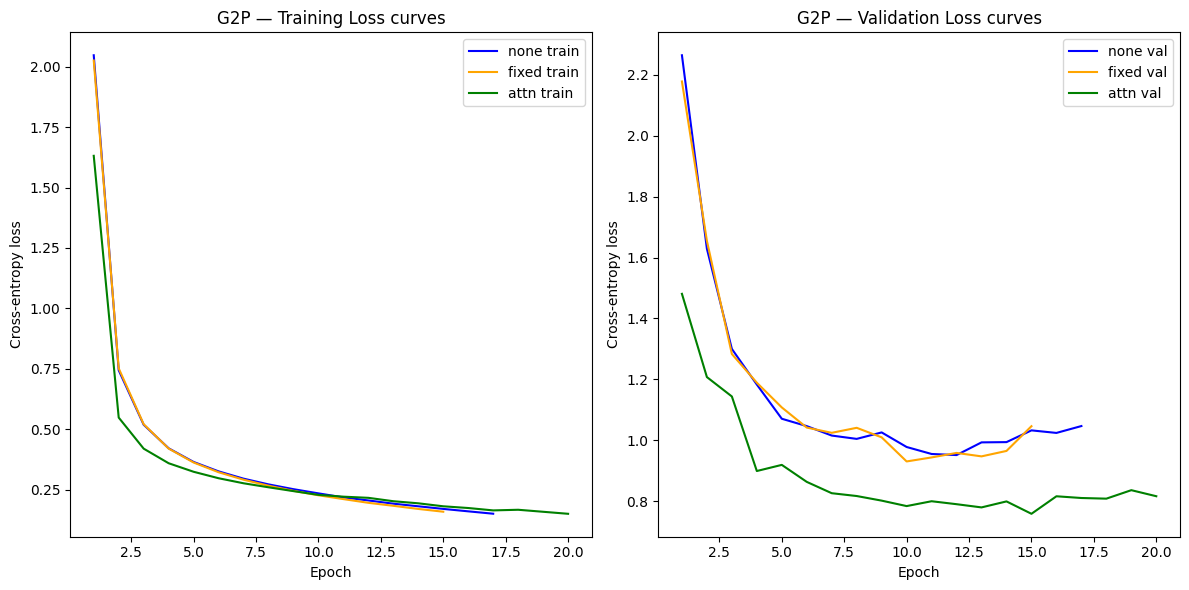

In [ ]:
histories = {
    "none": no_context_history,
    "fixed": fixed_context_history,
    "attn": attn_context_history
}
colours = {
    "none": "blue",
    "fixed": "orange",
    "attn": "green"
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
for name, hist in histories.items():
    epochs = range(1, len(hist["train_loss"]) + 1)
    ax1.plot(epochs, hist["train_loss"], color=colours[name], label=f"{name} train")
    ax2.plot(epochs, hist["val_loss"], color=colours[name], label=f"{name} val")
    
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-entropy loss')
ax1.set_title('G2P — Training Loss curves')
ax1.legend()

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Cross-entropy loss')
ax2.set_title('G2P — Validation Loss curves')
ax2.legend()

plt.tight_layout()
plt.show()

In [26]:
none_context_loss, none_context_acc, none_context_per = evaluate(
    model=no_context_model, 
    loader=test_loader, 
    criterion = none_context_criterion, 
    device=device)

fixed_context_loss, fixed_context_acc, fixed_context_per = evaluate(
    model=fixed_context_model, 
    loader=test_loader, 
    criterion = fixed_context_criterion, 
    device=device)

attn_context_loss, attn_context_acc, attn_context_per = evaluate(
    model=attn_context_model, 
    loader=test_loader, 
    criterion = attn_context_criterion, 
    device=device)


In [27]:
summary_df = pd.DataFrame({
    "model": ["none", "fixed", "attn"],

    "test_loss": [
        none_context_loss,
        fixed_context_loss,
        attn_context_loss,
    ],

    "test_acc": [
        none_context_acc,
        fixed_context_acc,
        attn_context_acc,
    ],

    "test_per": [
        none_context_per,
        fixed_context_per,
        attn_context_per,
    ],
    "stopping epoch": [
        len(no_context_history["val_per"]),
        len(fixed_context_history["val_per"]),
        len(attn_context_history["val_per"]),
    ],
})

print(summary_df)


   model  test_loss  test_acc  test_per  stopping epoch
0   none   1.096418  0.571317  0.129680              17
1  fixed   1.102851  0.561018  0.133954              15
2   attn   0.881183  0.586723  0.117885              20


## Error Comparison

In [ ]:
error_test_loader = DataLoader(test_dataset, collate_fn=collate_with_padding,batch_size=1, shuffle=False, num_workers=0)

SPECIAL = {0, 1, 2, 3}  # PAD, SOS, EOS, UNK

def ids_to_word(ids):
    return "".join(index_to_char.get(i, "") for i in ids if i not in SPECIAL)

def ids_to_phonemes(ids):
    return " ".join(index_to_phoneme.get(i, "") for i in ids if i not in SPECIAL)


def find_errors(model_names, loader, device=device, num_test=10):

    fails = {name: set()  for name in model_names.values()}
    preds = {name: {}     for name in model_names.values()}

    with torch.no_grad():
        for i, (src, tgt) in enumerate(loader):
            if i >= num_test:
                break

            src, tgt   = src.to(device), tgt.to(device)
            target_out = tgt[:, 1:]          # exclude <SOS>
            tgt_len    = target_out.size(1)

            target_out   = remove_padding(target_out)

            # Decode the word string 
            word = ids_to_word(src[0].cpu().tolist())

            for model in model_names:
                model.eval()
                _, pred_ids, _ = model.greedy_decode(src)

                pred_ids = remove_padding(pred_ids)

                c, t = calc_word_acc_component(pred_ids, target_out)
                if t == 0:
                    continue

                name = model_names[model]
                tgt_str = ids_to_phonemes(target_out[0])
                pred_str = ids_to_phonemes(pred_ids[0])

                preds[name][word] = {"tgt": tgt_str, "pred": pred_str}

                if c < t:                    # at least one token wrong = fail
                    fails[name].add(word)

    return fails, preds

def compare_fail_points(title:str, fail_set:set, all_preds:dict, max_len:int = 6):
    print()
    print(f"{title} ({len(fail_set)} words)")
    
    for word in sorted(fail_set, key=len, reverse=True)[:max_len]:
        p = all_preds["attn"][word]
        print(f"\n  Word      : {word}  (len={len(word)})")
        print(f"  Target    : {all_preds["attn"][word]['tgt']}")
        print(f"  Pred attn : {all_preds["attn"][word]['pred']}")
        print(f"  Pred fixed: {all_preds["fixed"][word]['pred']}")
        print(f"  Pred none : {all_preds["none"][word]['pred']}")
        
    print()


model_names = {
    no_context_model:    "none",
    fixed_context_model: "fixed",
    attn_context_model:  "attn",
}

fails, preds = find_errors(model_names, error_test_loader, num_test=300)

none_fails  = fails["none"]
fixed_fails = fails["fixed"]
attn_fails  = fails["attn"]

# Set arithmetic 
only_none       = none_fails - fixed_fails - attn_fails
only_fixed      = fixed_fails - none_fails - attn_fails
only_attn       = attn_fails - none_fails - fixed_fails
none_not_attn   = none_fails - attn_fails   
none_not_fixed  = none_fails - fixed_fails
fixed_not_attn  = fixed_fails - attn_fails
fixed_not_none  = fixed_fails - none_fails
attn_not_none   = attn_fails - none_fails   
attn_not_fixed  = attn_fails - fixed_fails
all_fail        = none_fails & fixed_fails & attn_fails

print(f"Total words evaluated : {len(preds['none'])}")
print(f"Setup 1 (none)  fails : {len(none_fails)}")
print(f"Setup 2 (fixed) fails : {len(fixed_fails)}")
print(f"Setup 3 (attn)  fails : {len(attn_fails)}")
print()
print(f"Only none fails        : {len(only_none)}")
print(f"Only fixed fails       : {len(only_fixed)}")
print(f"Only attn fails        : {len(only_attn)}")
print(f"None fails, attn wins  : {len(none_not_attn)}")
print(f"None fails, fixed wins : {len(none_not_fixed)}")
print(f"Fixed fails, none wins : {len(fixed_not_none)}")
print(f"Fixed fails, attn wins : {len(fixed_not_attn)}")
print(f"Attn fails, none wins  : {len(attn_not_none)}")
print(f"Attn fails, fixed wins : {len(attn_not_fixed)}")

print(f"All three fail         : {len(all_fail)}")

Total words evaluated : 300
Setup 1 (none)  fails : 188
Setup 2 (fixed) fails : 196
Setup 3 (attn)  fails : 265

Only none fails        : 7
Only fixed fails       : 3
Only attn fails        : 49
None fails, attn wins  : 20
None fails, fixed wins : 43
Fixed fails, none wins : 51
Fixed fails, attn wins : 16
Attn fails, none wins  : 97
Attn fails, fixed wins : 85
All three fail         : 132


In [30]:
compare_fail_points("only none fails", only_none,  preds)


only none fails (7 words)

  Word      : lawnmower  (len=9)
  Target    : L AO1 N M OW0 ER0
  Pred attn : L AO1 N M OW0 ER0
  Pred fixed: L AO1 N M OW0 ER0
  Pred none : L AO1 N M OW0 R UW2

  Word      : smoothest  (len=9)
  Target    : S M UW1 DH AH0 S T
  Pred attn : S M UW1 DH AH0 S T
  Pred fixed: S M UW1 DH AH0 S T
  Pred none : S M UW1 DH T S UW2

  Word      : mcmonagle  (len=9)
  Target    : M AH0 K M AA1 N AH0 G AH0 L
  Pred attn : M AH0 K M AA1 N AH0 G AH0 L
  Pred fixed: M AH0 K M AA1 N AH0 G AH0 L
  Pred none : M AH0 K AA1 M AH0 N AH0 L

  Word      : rendell  (len=7)
  Target    : R EH1 N D AH0 L
  Pred attn : R EH1 N D AH0 L
  Pred fixed: R EH1 N D AH0 L
  Pred none : R IY0 N D EH1 L AH0 L

  Word      : whinney  (len=7)
  Target    : W IH1 N IY0
  Pred attn : W IH1 N IY0
  Pred fixed: W IH1 N IY0
  Pred none : W IH1 N IH0 N

  Word      : pastor  (len=6)
  Target    : P AE1 S T ER0
  Pred attn : P AE1 S T ER0
  Pred fixed: P AE1 S T ER0
  Pred none : P AE1 S T AO0 R



In [31]:
compare_fail_points("only fixed fails", only_fixed,  preds)


only fixed fails (3 words)

  Word      : stereotyped  (len=11)
  Target    : S T EH1 R IY0 AH0 T AY2 P T
  Pred attn : S T EH1 R IY0 AH0 T AY2 P T
  Pred fixed: S T EH1 R IY0 OW0 T AY2 P T
  Pred none : S T EH1 R IY0 AH0 T AY2 P T

  Word      : approached  (len=10)
  Target    : AH0 P R OW1 CH T
  Pred attn : AH0 P R OW1 CH T
  Pred fixed: AH0 P R OW1 CH AH0 D
  Pred none : AH0 P R OW1 CH T

  Word      : turrets  (len=7)
  Target    : T ER1 AH0 T S
  Pred attn : T ER1 AH0 T S
  Pred fixed: T ER1 IH0 S T
  Pred none : T ER1 AH0 T S



In [32]:
compare_fail_points("only attn fails", only_attn,  preds)


only attn fails (49 words)

  Word      : decommissioned  (len=14)
  Target    : D IY0 K AH0 M IH1 SH AH0 N D
  Pred attn : D IY2 K AA2 M IH0 S AA1 N AH0 S
  Pred fixed: D IY0 K AH0 M IH1 SH AH0 N D
  Pred none : D IY0 K AH0 M IH1 SH AH0 N D

  Word      : undertaker  (len=10)
  Target    : AH1 N D ER0 T EY2 K ER0
  Pred attn : AH1 N D ER0 T AE2 K ER0
  Pred fixed: AH1 N D ER0 T EY2 K ER0
  Pred none : AH1 N D ER0 T EY2 K ER0

  Word      : resistence  (len=10)
  Target    : R IH0 Z IH1 S T AH0 N S
  Pred attn : R EH1 Z IH0 S T AH0 N S
  Pred fixed: R IH0 Z IH1 S T AH0 N S
  Pred none : R IH0 Z IH1 S T AH0 N S

  Word      : castrating  (len=10)
  Target    : K AE1 S T R EY2 T IH0 NG
  Pred attn : K AE1 S T R AH0 T IH0 NG
  Pred fixed: K AE1 S T R EY2 T IH0 NG
  Pred none : K AE1 S T R EY2 T IH0 NG

  Word      : simplified  (len=10)
  Target    : S IH1 M P L AH0 F AY2 D
  Pred attn : S IH0 M P L IH1 F IY0 D
  Pred fixed: S IH1 M P L AH0 F AY2 D
  Pred none : S IH1 M P L AH0 F AY2 D



In [33]:
compare_fail_points("all fail", all_fail,  preds, max_len=5)


all fail (132 words)

  Word      : eccentricities  (len=14)
  Target    : EH2 K S EH0 N T R IH1 S IH0 T IY0 Z
  Pred attn : EH2 S AH0 N T R IH1 S AH0 T IY0 Z
  Pred fixed: EH0 K S EH2 N T R IH1 S IH0 T IY0 Z
  Pred none : EH2 K S AH0 N T R IH1 S AH0 T IY0 Z

  Word      : photosynthesis  (len=14)
  Target    : F OW2 T OW0 S IH1 N TH AH0 S IH0 S
  Pred attn : F OW1 T OW0 S IH2 N TH AH0 S IH0 S
  Pred fixed: F OW2 T OW0 S IH1 N TH IY0 AH0 S T S
  Pred none : F OW2 T AH0 Z IH1 N TH S AH0 N

  Word      : vulgarization  (len=13)
  Target    : V AH2 L G ER0 IH0 Z EY1 SH AH0 N
  Pred attn : V L AH0 G ER0 AH0 Z EY1 SH AH0 N
  Pred fixed: V AH2 L G R IH0 Z EY1 R IH0 T AH0 N
  Pred none : V AH2 L G ER0 AH0 Z EY1 SH AH0 N

  Word      : restauranteur  (len=13)
  Target    : R EH0 S T R AA0 N T ER1
  Pred attn : R IH0 S T AA0 R AA0 N T UH1 R
  Pred fixed: R EH2 S T ER0 AH0 N T AO1 R IY0
  Pred none : R EH2 S T ER0 AH0 N T UH1 R

  Word      : dickensheets  (len=12)
  Target    : D IH1 K AH0 N S

# Attention Analysis 

In [34]:
sample_texts = [
    "conservationists",
    "rancorousness",
    "electrocardiograms",
    "pronunciations",
    "jennifer",
    "core",
]

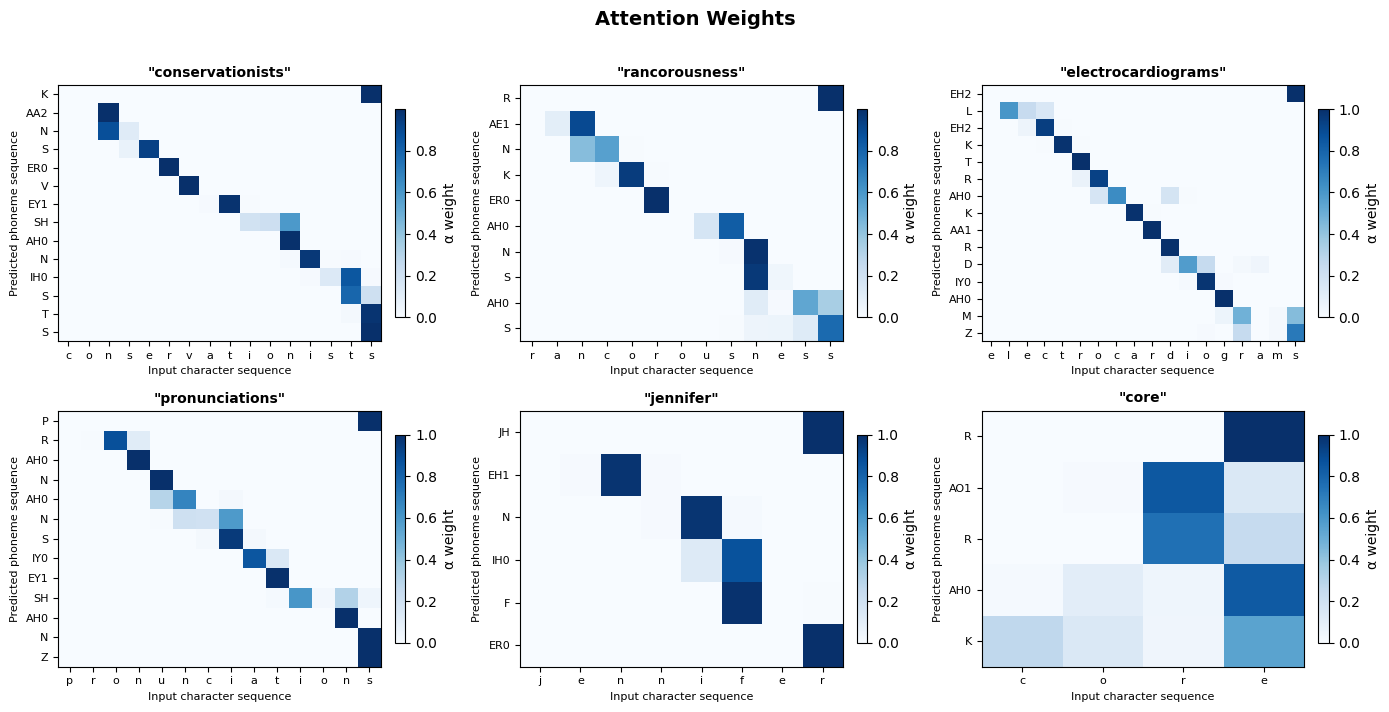

In [ ]:
def attn_analysis(model, sample_texts, char_to_idx, idx_to_phoneme,
                  device, max_len=30):
    model.eval()

    unk = char_to_idx["<UNK>"]
    eos = char_to_idx["<EOS>"]
    pad = char_to_idx["<PAD>"]

    n_texts = len(sample_texts)
    n_cols  = 3
    n_rows  = 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 7))
    axes = axes.flatten()  

    for i, sample_text in enumerate(sample_texts):
        ax = axes[i]

        # encode 
        src_tokens = list(sample_text)
        ids = [char_to_idx.get(c, unk) for c in src_tokens]
        src = torch.tensor([ids], dtype=torch.long, device=device)

        # decode 
        logits, generated, attn_weights = model.greedy_decode(src)
        attn_matrix = attn_weights[:, 0, :].cpu().numpy()  # (tgt_steps, src_len)

        # build target labels
        tgt_labels = []
        for idx in generated[0].cpu().tolist():
            if idx == eos:
                break
            if idx != pad:
                tgt_labels.append(idx_to_phoneme.get(idx, "<UNK>"))

        # trim rows / cols 
        n_steps     = min(len(tgt_labels), attn_matrix.shape[0])
        attn_matrix = attn_matrix[:n_steps, :len(src_tokens)]
        tgt_labels  = tgt_labels[:n_steps]
        src_len     = len(src_tokens)

        # plot 
        im = ax.imshow(attn_matrix, cmap="Blues", aspect="auto",
                       vmin=0.0, vmax=attn_matrix.max())
        ax.set_xticks(range(src_len))
        ax.set_xticklabels(list(sample_text), fontsize=8)
        ax.set_yticks(range(n_steps))
        ax.set_yticklabels(tgt_labels, fontsize=8)
        ax.set_xlabel("Input character sequence", fontsize=8)
        ax.set_ylabel("Predicted phoneme sequence", fontsize=8)
        ax.set_title(f'"{sample_text}"', fontsize=10, fontweight="bold")
        fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label="α weight")

    fig.suptitle("Attention Weights", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


attn_analysis(attn_context_model, sample_texts, char_to_index,
                  index_to_phoneme, device=device)

# 6. Hyperparamter Tuning 

## Search Space 

In [36]:
PAD_IDX = 0
TUNING_EPOCH = 5

search_space = {
    "lr":        [1e-5, 1e-4, 1e-3],
    "embed_dim":   [32, 64, 128],
    "hidden_size": [64, 128, 256],
}

best_config = None
best_val_per = float("inf")
results = []

## Grid Search 

In [37]:
tune_hp = True
if tune_hp:
    for lr in search_space["lr"]:
        for em_dim in search_space["embed_dim"]:
            for h_dim in search_space["hidden_size"]:
                print(
                    f"lr={lr} | "
                    f"embed_dim={em_dim} | "
                    f"hidden_size={h_dim}"
                )
        
                no_context_encoder = Encoder(
                    src_vocab_size=CHAR_VOCAB_SIZE,
                    embed_dim=em_dim,
                    hidden_size=h_dim,
                )
        
                no_context_decoder = Decoder(
                    tgt_vocab_size=PHONEME_VOCAB_SIZE,
                    embed_dim=em_dim,
                    hidden_size=h_dim,
                    context_mode="none"
                )
        
                no_context_model = Seq2Seq(
                    no_context_encoder,
                    no_context_decoder,
                ).to(device)
        
                criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
                optimiser = optim.Adam(no_context_model.parameters(), lr=lr)
                history = train_val_model(model=no_context_model,
                                          train_loader=train_loader,
                                          eval_loader=val_loader, 
                                          optimiser=optimiser,
                                          criterion=criterion,
                                          num_epochs=TUNING_EPOCH
                                          )
        
                final_val_loss = history["val_loss"][-1]
                final_val_acc  = history["val_acc"][-1]
                final_val_per  = history["val_per"][-1]
        
                val_per = history["val_per"]
                best_idx = 0
                best_value = val_per[0]
        
                for i, value in enumerate(val_per):
                    if value < best_value:
                        best_value = value
                        best_idx = i
        
                best_epoch_per = history["val_per"][best_idx]
                best_epoch_acc = history["val_acc"][best_idx]
                best_epoch_loss = history["val_loss"][best_idx]
                best_epoch = best_idx + 1
        
        
                config_result = {
                    "lr": lr,
                    "embed_dim": em_dim,
                    "hidden_size": h_dim,
        
                    "final_val_loss": final_val_loss,
                    "final_val_acc": final_val_acc,
                    "final_val_per": final_val_per,
        
                    "best_epoch": best_epoch,
                    "best_epoch_per": best_epoch_per,
                    "best_epoch_acc": best_epoch_acc,
                    "best_epoch_loss": best_epoch_loss
                }
        
                if best_epoch_per < best_val_per:
                    best_val_per = best_epoch_per
                    best_config = config_result
        
                    print(
                        f"Best epoch PER: {best_epoch_per:.4f} at epoch {best_epoch}"
                    )
        
                results.append(config_result)

lr=1e-05 | embed_dim=32 | hidden_size=64
Epoch 01/5  Train loss=4.2829 acc=0.000 per=2.617  Val loss=4.2887 acc=0.000 per=2.508  
Epoch 02/5  Train loss=4.2487 acc=0.000 per=2.556  Val loss=4.2599 acc=0.000 per=2.485  
Epoch 03/5  Train loss=4.1994 acc=0.000 per=2.200  Val loss=4.2129 acc=0.000 per=2.555  
Epoch 04/5  Train loss=4.1023 acc=0.000 per=1.412  Val loss=4.2229 acc=0.000 per=0.963  
Epoch 05/5  Train loss=3.7382 acc=0.000 per=0.968  Val loss=4.1722 acc=0.000 per=0.967  
Best epoch PER: 0.9630 at epoch 4
lr=1e-05 | embed_dim=32 | hidden_size=128
Epoch 01/5  Train loss=4.2654 acc=0.000 per=1.525  Val loss=4.2740 acc=0.000 per=0.964  
Epoch 02/5  Train loss=4.1829 acc=0.000 per=0.986  Val loss=4.2540 acc=0.000 per=1.000  
Epoch 03/5  Train loss=3.6661 acc=0.000 per=0.990  Val loss=4.1653 acc=0.000 per=0.954  
Epoch 04/5  Train loss=3.3948 acc=0.000 per=0.919  Val loss=3.9379 acc=0.000 per=0.887  
Epoch 05/5  Train loss=3.3387 acc=0.000 per=0.895  Val loss=3.8196 acc=0.000 per=0

## Result

In [38]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="best_epoch_per",
    ascending=True
)

print("\nTop configurations:")
print(results_df)

print("\nBest configuration:")
print(best_config)


Top configurations:
         lr  embed_dim  hidden_size  final_val_loss  final_val_acc  \
26  0.00100        128          256        1.073149       0.496581   
23  0.00100         64          256        1.142084       0.468709   
20  0.00100         32          256        1.137553       0.446897   
25  0.00100        128          128        1.538877       0.356617   
22  0.00100         64          128        1.570508       0.343547   
19  0.00100         32          128        1.651673       0.316368   
24  0.00100        128           64        2.156234       0.207738   
21  0.00100         64           64        2.263726       0.178049   
18  0.00100         32           64        2.302296       0.139617   
17  0.00010        128          256        2.439334       0.103350   
14  0.00010         64          256        2.681169       0.045962   
16  0.00010        128          128        2.902485       0.023024   
11  0.00010         32          256        2.793082       0.015321   